# Pancreatic Cancer CRISPR Session 1

## Goal

Investigate how the same eight selected CRISPR activation targets behave under **two drugs in Panc-1 cells**. You will change two small code settings, use a score and an FDR rule to make shortlists, inspect a chart, choose a gene, and use a biological reference to explain a plausible mechanism. Allow about **50 minutes**.

**Your work matters:** this is a blank starter notebook. Run the cells yourself, change the marked lines, and type your own answers at the end. The values come from Ramaker et al., *BMC Cancer* 21, 632 (2021), [article and Additional file 1](https://link.springer.com/article/10.1186/s12885-021-08388-1), Table S3A. The eight selected rows are keyed by the source `Gene_ID` (one chosen entry per gene symbol); they are a teaching subset of the CRISPR activation (SAM) screen, not a genome-wide ranking.

**Read the measurements carefully.** `L2FC Sum` is the authors’ processed gene-level ranking score, derived from the two strongest guides’ replicate-minimum log₂ changes. A more positive value means stronger guide enrichment after drug treatment. It is **not** a cell-survival percentage or a simple fold change for the gene. `FDR` (false discovery rate) is the authors’ reported, multiple-testing-adjusted evidence measure for that condition; you will read it, not calculate it. Neither value alone proves mechanism or patient response.

## Setup

Run each code cell with the ▶ button at its left (or Shift+Enter), from top to bottom. Wait for an output before continuing. No data upload or package installation is required. When a step asks you to edit, change **only the text or number after `=`** on the marked line.

## Steps

### 1. Load and inspect the source entries

Run the next cell. Confirm that the table has **eight rows**, two drugs, and a score plus FDR for each drug. One row is a selected source `Gene_ID`, not one cell or one sgRNA.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Eight exact entries from Table S3A; columns P1_Irinotecan and P1_Oxaliplatin.
source_rows = [
    {'Gene_ID': 'NM_000927', 'Gene': 'ABCB1', 'irinotecan_score': -0.385042546, 'irinotecan_fdr': 0.196287526, 'oxaliplatin_score': 3.647190058, 'oxaliplatin_fdr': 0.000903943},
    {'Gene_ID': 'NM_005359', 'Gene': 'SMAD4', 'irinotecan_score': 0.84063055, 'irinotecan_fdr': 0.081851215, 'oxaliplatin_score': 1.265636529, 'oxaliplatin_fdr': 0.087198874},
    {'Gene_ID': 'NM_004827', 'Gene': 'ABCG2', 'irinotecan_score': 5.838822517, 'irinotecan_fdr': 0.000329514, 'oxaliplatin_score': 1.390071685, 'oxaliplatin_fdr': 0.068305333},
    {'Gene_ID': 'NM_004739', 'Gene': 'MTA2', 'irinotecan_score': 3.183901633, 'irinotecan_fdr': 0.006667503, 'oxaliplatin_score': 0.692755902, 'oxaliplatin_fdr': 0.239555459},
    {'Gene_ID': 'NM_004996', 'Gene': 'ABCC1', 'irinotecan_score': 1.51239105, 'irinotecan_fdr': 0.043951755, 'oxaliplatin_score': 0.178963744, 'oxaliplatin_fdr': 0.470358607},
    {'Gene_ID': 'NM_002467', 'Gene': 'MYC', 'irinotecan_score': 4.941571514, 'irinotecan_fdr': 0.000442243, 'oxaliplatin_score': -0.273578784, 'oxaliplatin_fdr': 0.689020185},
    {'Gene_ID': 'NM_001273', 'Gene': 'CHD4', 'irinotecan_score': 2.795522587, 'irinotecan_fdr': 0.011086013, 'oxaliplatin_score': 4.847384321, 'oxaliplatin_fdr': 0.000718232},
    {'Gene_ID': 'NM_003286', 'Gene': 'TOP1', 'irinotecan_score': -0.87410419, 'irinotecan_fdr': 0.25737575, 'oxaliplatin_score': -0.882943047, 'oxaliplatin_fdr': 0.895186973},
]
data = pd.DataFrame(source_rows)
print(f"Selected entries: {len(data)}; gene symbols: {data['Gene'].nunique()}")
display(data.round(3))

Selected entries: 8; gene symbols: 8


,Gene_ID,Gene,irinotecan_score,irinotecan_fdr,oxaliplatin_score,oxaliplatin_fdr
0,NM_000927,ABCB1,-0.385,0.196,3.647,0.001
1,NM_005359,SMAD4,0.841,0.082,1.266,0.087
2,NM_004827,ABCG2,5.839,0.000,1.390,0.068
3,NM_004739,MTA2,3.184,0.007,0.693,0.240
4,NM_004996,ABCC1,1.512,0.044,0.179,0.470
5,NM_002467,MYC,4.942,0.000,-0.274,0.689
6,NM_001273,CHD4,2.796,0.011,4.847,0.001
7,NM_003286,TOP1,-0.874,0.257,-0.883,0.895


### 2. Set the comparison

**Run A:** Leave `DRUG` as `"irinotecan"` and `MIN_SCORE` as `1.0`. Run this settings cell, then the shortlist cell below; record its count and gene names in your answers.

**Run B:** Change **only** `MIN_SCORE` to `3.0`. Rerun this settings cell **and** the shortlist cell. Record the new list.

**Run C:** Restore `MIN_SCORE` to `1.0` and change `DRUG` to `"oxaliplatin"`. Rerun **both** cells. Record the list. Leave `MAX_FDR` at `0.05` for all three runs.

The **classroom shortlist rule** is `L2FC Sum ≥ MIN_SCORE` **and** `FDR < 0.05`. The score cutoff is a teaching choice, not the authors’ claimed hit threshold. Passing the rule prioritizes follow-up; it does not prove resistance.

In [6]:
# EDIT ONLY these two marked values for Runs A, B, and C.
DRUG = "oxaliplatin"     # change to "oxaliplatin" for Run C
MIN_SCORE = 1.0          # change to 3.0 for Run B; restore 1.0 for Run C
MAX_FDR = 0.05          # leave this unchanged
print(f"Selected: {DRUG}, score cutoff {MIN_SCORE}, FDR cutoff {MAX_FDR}")

Selected: oxaliplatin, score cutoff 1.0, FDR cutoff 0.05


In [7]:
# Run this cell again after EACH settings change.
if DRUG not in ("irinotecan", "oxaliplatin"):
    raise ValueError('DRUG must be exactly "irinotecan" or "oxaliplatin".')
score_column = f"{DRUG}_score"
fdr_column = f"{DRUG}_fdr"
ranked = data[["Gene", score_column, fdr_column]].rename(
    columns={score_column: "L2FC Sum", fdr_column: "FDR"}
).sort_values("L2FC Sum", ascending=False)
shortlist = ranked[(ranked["L2FC Sum"] >= MIN_SCORE) & (ranked["FDR"] < MAX_FDR)]
print(f"{DRUG.title()} ranked scores — all eight selected entries")
display(ranked.round({"L2FC Sum":2,"FDR":4}).reset_index(drop=True))
print(f"Classroom shortlist: {len(shortlist)} of 8 entries")
display(shortlist.round({"L2FC Sum":2,"FDR":4}).reset_index(drop=True))

Oxaliplatin ranked scores — all eight selected entries


,Gene,L2FC Sum,FDR
0,CHD4,4.85,0.0007
1,ABCB1,3.65,0.0009
2,ABCG2,1.39,0.0683
3,SMAD4,1.27,0.0872
4,MTA2,0.69,0.2396
5,ABCC1,0.18,0.4704
6,MYC,-0.27,0.6890
7,TOP1,-0.88,0.8952


Classroom shortlist: 2 of 8 entries


,Gene,L2FC Sum,FDR
0,CHD4,4.85,0.0007
1,ABCB1,3.65,0.0009


### 3. Compare the two drugs visually

After Run C, run the next cell. The bars show **scores** for both drugs in the same Panc-1 cells. Use the table from Step 2 for FDR. A positive bar does not automatically meet the classroom rule.

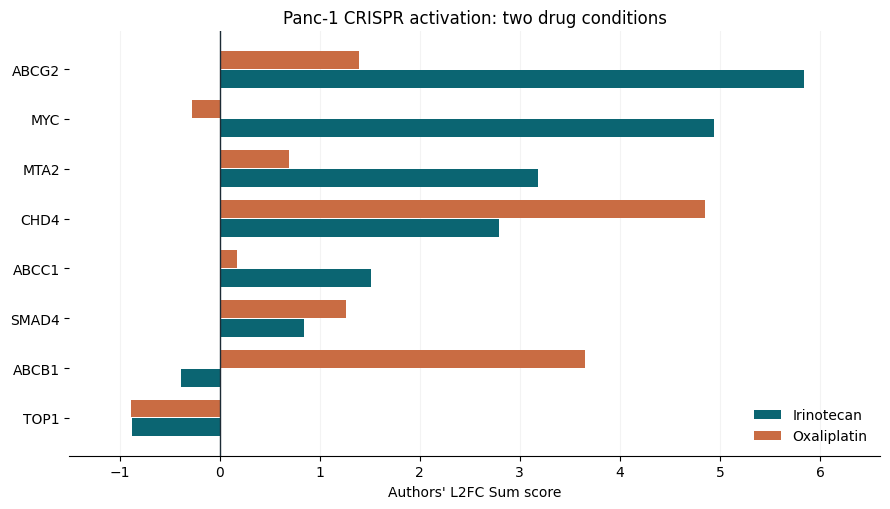

In [8]:
plot_data = data.sort_values("irinotecan_score").reset_index(drop=True)
y = list(range(len(plot_data)))
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh([i - 0.19 for i in y], plot_data["irinotecan_score"], height=0.36,
        label="Irinotecan", color="#0B6572")
ax.barh([i + 0.19 for i in y], plot_data["oxaliplatin_score"], height=0.36,
        label="Oxaliplatin", color="#C96C43")
ax.set_yticks(y, plot_data["Gene"])
ax.axvline(0, color="#1C2B35", linewidth=1)
ax.set(xlabel="Authors' L2FC Sum score", title="Panc-1 CRISPR activation: two drug conditions")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top","right","left"]].set_visible(False)
ax.grid(axis="x", alpha=0.15)
ax.set_axisbelow(True)
ax.set_xlim(-1.5, 6.6)
fig.tight_layout()
plt.show()

### 4. Choose and inspect one gene

Edit `GENE_TO_INSPECT` to **one** symbol from the eight rows (for example `"ABCB1"`, `"CHD4"`, or `"MYC"`), then run the cell. The code will subtract **oxaliplatin score from irinotecan score**. Record both scores, both FDRs, and the signed difference. A score difference is **not** a difference in survival percentage.

In [9]:
GENE_TO_INSPECT = "ABCG2"  # REQUIRED: type one gene symbol between the quotes.

if GENE_TO_INSPECT not in set(data["Gene"]):
    print("Choose a gene from the eight-row table, type it between the quotes, and rerun this cell.")
else:
    selected = data.loc[data["Gene"] == GENE_TO_INSPECT].iloc[0]
    difference = selected["irinotecan_score"] - selected["oxaliplatin_score"]
    print(f"{GENE_TO_INSPECT}: irinotecan score {selected['irinotecan_score']:+.2f}, "
          f"FDR {selected['irinotecan_fdr']:.4f}")
    print(f"{GENE_TO_INSPECT}: oxaliplatin score {selected['oxaliplatin_score']:+.2f}, "
          f"FDR {selected['oxaliplatin_fdr']:.4f}")
    print(f"Score difference (irinotecan − oxaliplatin): {difference:+.2f}")

ABCG2: irinotecan score +5.84, FDR 0.0003
ABCG2: oxaliplatin score +1.39, FDR 0.0683
Score difference (irinotecan − oxaliplatin): +4.45


## Checks

You should see an eight-row source table, a ranked table and a classroom shortlist after **each** settings run, one two-color chart, and a printed two-drug comparison for your chosen gene. The shortlist should change at least once across Runs A, B, and C. If a later cell says a variable is undefined, rerun from Step 1. If a gene is not recognized, check spelling and capitalization against the source table.

## Biological reference

Open [NCBI Gene](https://www.ncbi.nlm.nih.gov/gene/) and search your selected symbol **plus “Homo sapiens.”** Open the human gene page. Find the gene’s molecular function and where the protein acts in the cell; the page may link to supporting resources. Use your own words and save the exact page URL. If NCBI is unavailable, use the article’s Results section and state that source.

## Your answers

**Name:** Kamille

Double-click this cell and type after each **Answer:**. Press Shift+Enter to display your writing. Give concise, evidence-based answers; distinguish what you observed from what you hypothesize.

1. **Read the data.** What does one row represent, and why would dividing this L2FC Sum score by two **not** give a gene-expression fold change?
   
   Answer:One row represents one selected Gene ID from the CRISPR activation screen. L2FC Sum is a ranking score based on the two strongest guides, not a measurement of gene expression, so dividing it by two would not give a gene-expression fold change.

2. **Test the cutoff.** List the genes on Run A's classroom shortlist (`irinotecan`, score ≥1.0, FDR <0.05). Then list the genes on Run B's shortlist (score ≥3.0). Which genes leave, and what changed in the rule? Is 3.0 a p-value?
   
   Answer:Run A: ABCG2, MYC, MTA2, CHD4, and ABCC1. Run B: ABCG2, MYC, and MTA2. CHD4 and ABCC1 leave because the score cutoff increased from 1.0 to 3.0. 3.0 is a score cutoff, not a p-value.

3. **Compare drugs and evidence.** List the genes on Run C's oxaliplatin shortlist. ABCG2 has a positive oxaliplatin score; use its **score and FDR** to explain why it is absent under this rule. Does absence show no biological effect?
   
   Answer:Run C: CHD4 and ABCB1. ABCG2 has a positive oxaliplatin score of +1.39, but its FDR is 0.0683, which is above the 0.05 cutoff. Its absence does not mean there is no biological effect; it only means it did not pass the classroom rule.

4. **Interpret your chosen gene.** Report its two scores, two FDRs, and the signed score difference. Describe the drug pattern in these Panc-1 data without calling the score a survival percentage.
   
   Answer:ABCG2 has an irinotecan score of +5.84 (FDR 0.0003) and an oxaliplatin score of +1.39 (FDR 0.0683). The signed difference is +4.45. ABCG2 shows stronger and better-supported enrichment with irinotecan than oxaliplatin.

5. **Use cell biology.** Give your selected gene's human NCBI Gene URL, a paraphrased function and subcellular location, and one plausible mechanism that could connect its activation to your observed pattern. Label the mechanism as a hypothesis.
   
   Answer:ABCG2 is a membrane transporter that uses ATP to move substances across the cell membrane and can contribute to multidrug resistance. It mainly acts at the plasma membrane. Hypothesis: Activating ABCG2 may increase drug efflux, lowering the amount of drug inside the cells and contributing to the stronger enrichment seen with irinotecan.

6. **Test causation.** Propose an independent experiment using a gene-targeting CRISPR activation guide and a non-targeting guide in Panc-1 cells. Include a check that activation worked, the relevant drug treatment, one viability readout, and the result that would support your hypothesis.
   
   Answer:Use an ABCG2-targeting CRISPR activation guide and a non-targeting control guide in Panc-1 cells. Confirm that ABCG2 expression increased, treat both groups with irinotecan, and measure cell viability. Higher viability in the ABCG2-activated cells compared with the control would support the hypothesis.

## Next Steps

Download the notebook from Colab's **File** menu as an `.ipynb` file and submit it. Your edited settings, outputs, chosen gene, source URL, and written answers should be visible. The screen provides candidates; the independent test asks whether the perturbation actually changes the drug response.